In [1]:
# All in Runner
## Importing the libraries
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, random_split
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from torchinfo import summary
import torch.nn.functional as F
from torch.nn import init
from A_00_models import CNNAutoencoder, ResLinearAutoencoder, LSTMAutoencoder
from model_configs import ModelDimConfigs, TrainingConfigs
from misc_tools import get_timestamp, ARPABET
from model_dataset import DS_Tools, Padder, TokenMap, NormalizerKeepShapeManual
from model_dataset import SingleRecSelectBalanceDatasetPrecombine as ThisDataset
from model_filter import XpassFilter
from paths import *
from ssd_paths import *
from misc_progress_bar import draw_progress_bar
from misc_recorder import *
from H_11_drawer import draw_learning_curve_and_accuracy
import argparse
















In [18]:
hyperpath = "../model_save/REC-08221130_15+15/reslin/lf/"
model_save_dir = "../model_save/REC-08221130_15+15/"

In [19]:
# Data Loader
def load_data(type="f", sel="full", load="train"):
    # Load MV_config
    with open(os.path.join(src_, "mv_config_20.pkl"), "rb") as file: 
        mv_config = pickle.load(file)

    normalize_mean, normalize_std = mv_config["mean"], mv_config["std"]

    if type == "l":
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            XpassFilter(cut_off_upper=500),
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH, 
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShapeManual(mean=normalize_mean, std=normalize_std)
        )
    elif type == "h": 
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            XpassFilter(cut_off_upper=10000, cut_off_lower=4000),
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH, 
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShapeManual(mean=normalize_mean, std=normalize_std)
        )
    else: 
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH, 
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShapeManual(mean=normalize_mean, std=normalize_std)
        )
    with open(os.path.join(src_, "no-stress-seg.dict"), "rb") as file:
        # Load the object from the file
        mylist = pickle.load(file)
        mylist.remove('AH') # we don't include this, it is too mixed. 

    if sel == "c": 
        select = ARPABET.intersect_lists(mylist, ARPABET.list_consonants())
    elif sel == "v":
        select = ARPABET.intersect_lists(mylist, ARPABET.list_vowels())
    else:
        select = mylist
    # Now you can use the loaded object
    mymap = TokenMap(mylist)
    if load == "train": 
        train_ds = ThisDataset(strain_cut_audio_, 
                            os.path.join(suse_, "guide_train.csv"), 
                            select=select, 
                            mapper=mymap, 
                            transform=mytrans)
        
        train_ds_indices = DS_Tools.read_indices(os.path.join(model_save_dir, f"train_{sel}.use"))
        use_train_ds = torch.utils.data.Subset(train_ds, train_ds_indices)
        train_loader = DataLoader(use_train_ds, batch_size=TrainingConfigs.BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=TrainingConfigs.LOADER_WORKER)
        
        return train_loader
    elif load == "valid":
        valid_ds = ThisDataset(strain_cut_audio_, 
                            os.path.join(suse_, "guide_validation.csv"), 
                            select=select, 
                            mapper=mymap,
                            transform=mytrans)
        valid_ds_indices = DS_Tools.read_indices(os.path.join(model_save_dir, f"valid_{sel}.use"))
        use_valid_ds = torch.utils.data.Subset(valid_ds, valid_ds_indices)
        valid_loader = DataLoader(use_valid_ds, batch_size=TrainingConfigs.BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=TrainingConfigs.LOADER_WORKER)
        return valid_loader

In [20]:
def draw_mel(src_mel, trg_mel, file_name="", src_title="Source Mel", trg_title="Target Mel"):

    src_mel = src_mel.cpu().detach().numpy()
    trg_mel = trg_mel.cpu().detach().numpy()

    plt.clf()
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(src_mel[0], aspect='auto', origin='lower', vmin=-2, vmax=2)
    axes[0].set_title(src_title)
    axes[1].imshow(trg_mel[0], aspect='auto', origin='lower', vmin=-2, vmax=2)
    axes[1].set_title(trg_title)

    display.clear_output(wait=True)
    display.display(plt.gcf())
    if file_name: 
        plt.savefig(file_name)

In [21]:
valid_loader_1 = load_data(type="l", load="valid") # target 
valid_loader_2 = load_data(type="f", load="valid") 

In [22]:
device = torch.device("cpu")
input_shape = (128, 1, 64, 32)
criterion = nn.MSELoss()

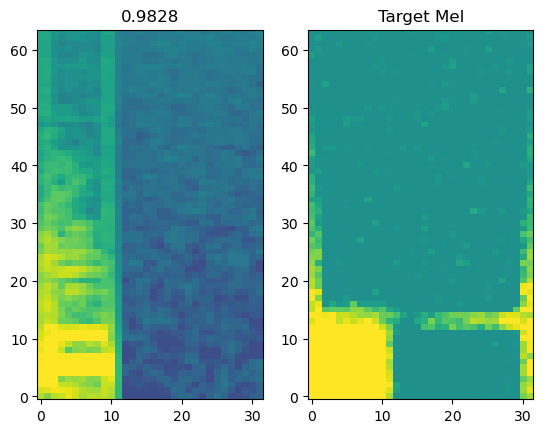

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

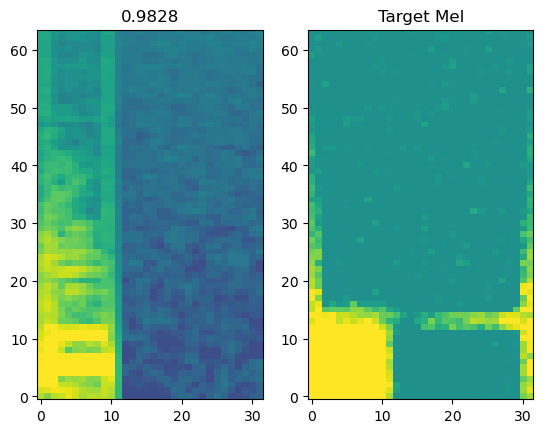

In [23]:
for epoch in range(0, 1): 
    model_path = hyperpath + f"{epoch}.pt"  # Update with your actual model file name
    model = ResLinearAutoencoder(input_shape=input_shape)  # Initialize your model class
    model.load_state_dict(torch.load(model_path))

    for idx, (x, _) in enumerate(valid_loader_1):
        if idx == 1:
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            mel_name = f"./reslin1/epoch_{epoch}_batch_{idx}_target.png"
            draw_mel(src_mel=x[0], trg_mel=x_rec[0], file_name=mel_name, src_title=f"{loss.item():.4f}")

    for idx, (x, _) in enumerate(valid_loader_2):
        if idx == 1:
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            mel_name = f"./reslin1/epoch_{epoch}_batch_{idx}_full.png"
            draw_mel(src_mel=x[0], trg_mel=x_rec[0], file_name=mel_name, src_title=f"{loss.item():.4f}")

In [47]:
x[0]

tensor([[[-0.9048, -0.7964, -1.0007,  ..., -0.9323, -0.8172, -0.6908],
         [-1.0059, -0.9505, -1.2057,  ..., -1.1672, -0.8590, -0.8579],
         [-0.7484, -1.0046, -1.1895,  ..., -0.8060, -0.5696, -0.4692],
         ...,
         [-0.4539, -0.5537, -0.5743,  ..., -0.3046, -0.3310, -0.4978],
         [-0.3499, -0.3773, -0.3969,  ..., -0.3467, -0.2769, -0.2604],
         [-0.3423, -0.2658, -0.2091,  ..., -0.4420, -0.3217, -0.2756]]])